<a href="https://colab.research.google.com/github/elviraasch/GEN-AI/blob/main/GEN_AI_TUGAS_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Text Classification with NLTK**

In [16]:
import sys
import nltk
import sklearn
import pandas as pd
import numpy as np

In [17]:
print('Python: {}'.format(sys.version))
print('NLTK: {}'.format(nltk.__version__))
print('Scikit-learn: {}'.format(sklearn.__version__))
print('Pandas: {}'.format(pd.__version__))
print('NumPy: {}'.format(np.__version__))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NLTK: 3.9.1
Scikit-learn: 1.6.1
Pandas: 2.2.2
NumPy: 2.0.2


In [18]:
sms = pd.read_table('/content/SMSSpamCollection', header=None, encoding='utf-8')
sms.head()

,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
sms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       5572 non-null   object
 1   1       5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [20]:
sms[0].value_counts()

,count
0,
ham,4825
spam,747


In [21]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
label = enc.fit_transform(sms[0])
print(label[:10])
print(sms[0][:10])

[0 0 1 0 0 1 0 0 1 1]
0     ham
1     ham
2    spam
3     ham
4     ham
5    spam
6     ham
7     ham
8    spam
9    spam
Name: 0, dtype: object


In [22]:
text = sms[1]
text[:10]

,1
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...
6,Even my brother is not like to speak with me. ...
7,As per your request 'Melle Melle (Oru Minnamin...
8,WINNER!! As a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...


In [23]:
# Use regular expression

# Replace email addresses with 'email'
processed = text.str.replace(r'^.+@[^\.].*\.[a-z]{2,}$', 'emailaddress')

# Replace URLs with 'webaddress'
processed = processed.str.replace(r'^http\://[a-zA-Z0-9\-\.]+\.[a-zA-Z]{2,3}(/\S*)?$', 'webaddress')

# Replace money symbols with 'moneysymb' (£ can by typed with ALT key + 156)
processed = processed.str.replace(r'£|\$', 'moneysymb')

# Replace 10 digit phone numbers (formats include paranthesis, spaces, no spaces, dashes) with 'phonenumber'
processed = processed.str.replace(r'^\(?[\d]{3}\)?[\s-]?[\d]{3}[\s-]?[\d]{4}$', 'phonenumbr')

# Replace numbers with 'numbr'
processed = processed.str.replace(r'\d+(\.\d+)?', 'numbr')

In [24]:
# Remove punctuation
processed = processed.str.replace(r'[^\w\d\s]', ' ')

# Replace whitespace between terms with a single space
processed = processed.str.replace(r'\s+', ' ')

# Remove leading and trailing whitespace
processed = processed.str.replace(r'^\s+|\s+?$', '')

In [25]:
processed = processed.str.lower()
processed

,1
0,"go until jurong point, crazy.. available only ..."
1,ok lar... joking wif u oni...
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."
...,...
5567,this is the 2nd time we have tried 2 contact u...
5568,will ü b going to esplanade fr home?
5569,"pity, * was in mood for that. so...any other s..."
5570,the guy did some bitching but i acted like i'd...


In [26]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords') # Add this line to download the stopwords corpus

stop_words = set(stopwords.words('english'))

processed = processed.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
ps = nltk.PorterStemmer()

processed = processed.apply(lambda x: ' '.join(ps.stem(term) for term in x.split()))

In [28]:
processed

,1
0,"go jurong point, crazy.. avail bugi n great wo..."
1,ok lar... joke wif u oni...
2,free entri 2 wkli comp win fa cup final tkt 21...
3,u dun say earli hor... u c alreadi say...
4,"nah think goe usf, live around though"
...,...
5567,2nd time tri 2 contact u. u £750 pound prize. ...
5568,ü b go esplanad fr home?
5569,"pity, * mood that. so...ani suggestions?"
5570,guy bitch act like interest buy someth els nex...


In [29]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab') # Download the specific 'punkt_tab' resource

all_words = []

for message in processed:
    words = word_tokenize(message)
    for w in words:
        all_words.append(w)

all_words = nltk.FreqDist(all_words)

# Print the result
print('Number of words: {}'.format(len(all_words)))
print('Most common words: {}'.format(all_words.most_common(15)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Number of words: 8920
Most common words: [('.', 4759), (',', 1939), ('?', 1550), ('!', 1397), ('...', 1146), ('u', 1138), ('&', 922), (';', 768), (':', 722), ('..', 697), ('call', 644), (')', 499), ('2', 478), ('go', 446), ('get', 446)]


In [30]:
# use the 1500 most common words as features
word_features = [x[0] for x in all_words.most_common(1500)]

In [31]:
def find_features(message):
    words = word_tokenize(message)
    features = {}
    for word in word_features:
        features[word] = (word in words)

    return features

In [32]:
features = find_features(processed[0])
for key, value in features.items():
    if value == True:
        print(key)

,
...
..
go
got
n
great
wat
e
world
point
avail
la
cine


In [33]:
list(features.items())[:10]

[('.', False),
 (',', True),
 ('?', False),
 ('!', False),
 ('...', True),
 ('u', False),
 ('&', False),
 (';', False),
 (':', False),
 ('..', True)]

In [34]:

messages = list(zip(processed, label))

np.random.seed(1)
np.random.shuffle(messages)

# Call find_features function for each SMS message
feature_set = [(find_features(text), label) for (text, label) in messages]

In [35]:
from sklearn.model_selection import train_test_split

training, test = train_test_split(feature_set, test_size=0.25, random_state=1)

In [36]:
print(len(training))
print(len(test))

4179
1393


In [37]:
from nltk.classify.scikitlearn import SklearnClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

names = ['K Nearest Neighbors', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SGD Classifier',
         'Naive Bayes', 'Support Vector Classifier']

classifiers = [
    KNeighborsClassifier(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    LogisticRegression(),
    SGDClassifier(max_iter=100),
    MultinomialNB(),
    SVC(kernel='linear')
]

models = zip(names, classifiers)

for name, model in models:
    nltk_model = SklearnClassifier(model)
    nltk_model.train(training)
    accuracy = nltk.classify.accuracy(nltk_model, test)
    print("{} model Accuracy: {}".format(name, accuracy))

K Nearest Neighbors model Accuracy: 0.9152907394113424
Decision Tree model Accuracy: 0.9569274946159368
Random Forest model Accuracy: 0.9791816223977028
Logistic Regression model Accuracy: 0.9806173725771715
SGD Classifier model Accuracy: 0.9770279971284996
Naive Bayes model Accuracy: 0.9877961234745154
Support Vector Classifier model Accuracy: 0.9827709978463748


In [38]:
from sklearn.ensemble import VotingClassifier

# Since VotingClassifier can accept list type of models
models = list(zip(names, classifiers))

nltk_ensemble = SklearnClassifier(VotingClassifier(estimators=models, voting='hard', n_jobs=-1))
nltk_ensemble.train(training)
accuracy = nltk.classify.accuracy(nltk_ensemble, test)
print("Voting Classifier model Accuracy: {}".format(accuracy))

Voting Classifier model Accuracy: 0.9813352476669059


In [39]:
text_features, labels = zip(*test)
prediction = nltk_ensemble.classify_many(text_features)

In [40]:
print(classification_report(labels, prediction))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1199
           1       0.99      0.87      0.93       194

    accuracy                           0.98      1393
   macro avg       0.99      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [41]:
pd.DataFrame( confusion_matrix(labels, prediction),
             index=[['actual', 'actual'], ['ham', 'spam']],
             columns = [['predicted', 'predicted'], ['ham', 'spam']])

predicted     
                  ham spam
actual ham       1198    1
       spam        25  169

# **RNN Basic**

In [42]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('Tensorflow: {}'.format(tf.__version__))

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

Tensorflow: 2.20.0


In [43]:
h = [1, 0, 0, 0]
e = [0, 1, 0, 0]
l = [0, 0, 1, 0]
o = [0, 0, 0, 1]

In [45]:
X_data = np.array([[h]], dtype=np.float32)
X_data.shape

(1, 1, 4)

In [46]:
hidden_size = 2
cell = tf.keras.layers.SimpleRNNCell(units=hidden_size)
rnn = tf.keras.layers.RNN(cell, return_sequences=True, return_state=True)
outputs, states = rnn(X_data)

print("X_data: {}, shape: {}".format(X_data, X_data.shape))
print("output: {}, shape: {}".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]]], shape: (1, 1, 4)
output: [[[ 0.10141081 -0.5134014 ]]], shape: (1, 1, 2)
states: [[ 0.10141081 -0.5134014 ]], shape: (1, 2)


In [47]:
rnn_2 = tf.keras.layers.SimpleRNN(units=hidden_size, return_sequences=True, return_state=True)
outputs, states = rnn_2(X_data)

print("X_data: {}, shape: {}".format(X_data, X_data.shape))
print("output: {}, shape: {}".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]]], shape: (1, 1, 4)
output: [[[-0.58770937  0.5279109 ]]], shape: (1, 1, 2)
states: [[-0.58770937  0.5279109 ]], shape: (1, 2)


In [48]:
X_data = np.array([[h, e, l, l, o]], dtype=np.float32)
X_data.shape

(1, 5, 4)

In [49]:
cell = tf.keras.layers.SimpleRNNCell(units=hidden_size)
rnn = tf.keras.layers.RNN(cell, return_sequences=True, return_state=True)
outputs, states = rnn(X_data)

print("X_data: {}, shape: {}\n".format(X_data, X_data.shape))
print("output: {}, shape: {}\n".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]], shape: (1, 5, 4)

output: [[[ 0.29921216  0.47373107]
  [-0.6101288  -0.49052048]
  [ 0.58422476 -0.25890324]
  [-0.4369524  -0.60243726]
  [ 0.7458221  -0.2629217 ]]], shape: (1, 5, 2)

states: [[ 0.7458221 -0.2629217]], shape: (1, 2)


In [50]:
X_data = np.array([[h, e, l, l, o],
                   [e, o, l, l, l],
                   [l, l, e, e, l]], dtype=np.float32)
X_data.shape

(3, 5, 4)

In [51]:
cell = tf.keras.layers.SimpleRNNCell(units=hidden_size)
rnn = tf.keras.layers.RNN(cell, return_sequences=True, return_state=True)
outputs, states = rnn(X_data)

print("X_data: {}, shape: {}\n".format(X_data, X_data.shape))
print("output: {}, shape: {}\n".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[0. 1. 0. 0.]
  [0. 0. 0. 1.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]]

 [[0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]]], shape: (3, 5, 4)

output: [[[ 0.7051796  -0.04144344]
  [ 0.40695983 -0.00954744]
  [ 0.6422467  -0.23553541]
  [ 0.7877656  -0.11987218]
  [ 0.9158328  -0.3702422 ]]

 [[-0.23175244  0.21667579]
  [ 0.4555106  -0.3026749 ]
  [ 0.72509974  0.01262835]
  [ 0.7809573  -0.36399338]
  [ 0.8462076  -0.05430712]]

 [[ 0.36439574 -0.09390572]
  [ 0.6379354  -0.14481132]
  [ 0.3876712   0.11116039]
  [ 0.08010731 -0.03000011]
  [ 0.4361312  -0.09658247]]], shape: (3, 5, 2)

states: [[ 0.9158328  -0.3702422 ]
 [ 0.8462076  -0.05430712]
 [ 0.4361312  -0.09658247]], shape: (3, 2)


# **RNN - Many-to-one**

In [52]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('Tensorflow: {}'.format(tf.__version__))

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

Tensorflow: 2.20.0


In [53]:
words = ['good', 'bad', 'worse', 'so good']
y = [1, 0, 0, 1]

In [54]:
char_set = ['<pad>'] + sorted(list(set(''.join(words))))
idx2char = {idx:char for idx, char in enumerate(char_set)}
char2idx = {char:idx for idx, char in enumerate(char_set)}

In [55]:
char_set

['<pad>', ' ', 'a', 'b', 'd', 'e', 'g', 'o', 'r', 's', 'w']

In [56]:
idx2char

{0: '<pad>',
 1: ' ',
 2: 'a',
 3: 'b',
 4: 'd',
 5: 'e',
 6: 'g',
 7: 'o',
 8: 'r',
 9: 's',
 10: 'w'}

In [57]:
char2idx

{'<pad>': 0,
 ' ': 1,
 'a': 2,
 'b': 3,
 'd': 4,
 'e': 5,
 'g': 6,
 'o': 7,
 'r': 8,
 's': 9,
 'w': 10}

In [58]:
X = list(map(lambda word: [char2idx.get(char) for char in word], words))
X_len = list(map(lambda word: len(word), X))

In [59]:
X

[[6, 7, 7, 4], [3, 2, 4], [10, 7, 8, 9, 5], [9, 7, 1, 6, 7, 7, 4]]

In [60]:
X_len

[4, 3, 5, 7]

In [61]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Padding the sequence of indices
max_sequence=10

X = pad_sequences(X, maxlen=max_sequence, padding='post', truncating='post')

In [62]:
X

array([[ 6,  7,  7,  4,  0,  0,  0,  0,  0,  0],
       [ 3,  2,  4,  0,  0,  0,  0,  0,  0,  0],
       [10,  7,  8,  9,  5,  0,  0,  0,  0,  0],
       [ 9,  7,  1,  6,  7,  7,  4,  0,  0,  0]], dtype=int32)

In [63]:
y

[1, 0, 0, 1]

In [64]:
# Generate data pipeline
train_ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(buffer_size=4).batch(batch_size=2)
print(train_ds)

<_BatchDataset element_spec=(TensorSpec(shape=(None, 10), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [65]:
input_dim = len(char2idx)
output_dim = len(char2idx)

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=input_dim, output_dim=output_dim,
              mask_zero=True, input_length=max_sequence,
              trainable=False, embeddings_initializer=tf.keras.initializers.random_normal()),
    SimpleRNN(units=10),
    Dense(2)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
def loss_fn(model, X, y):
    return tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_true=y,
                                                                          y_pred=model(X),
                                                                          from_logits=True))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [68]:
tr_loss_hist = []

for e in range(30):
    avg_tr_loss = 0
    tr_step = 0

    for x_mb, y_mb in train_ds:
        with tf.GradientTape() as tape:
            tr_loss = loss_fn(model, x_mb, y_mb)

        grads = tape.gradient(tr_loss, sources=model.variables)
        optimizer.apply_gradients(grads_and_vars=zip(grads, model.variables))
        avg_tr_loss += tr_loss
        tr_step += 1

    avg_tr_loss /= tr_step
    tr_loss_hist.append(avg_tr_loss)

    if (e + 1) % 5 == 0:
        print('epoch: {:3}, tr_loss: {:3f}'.format(e + 1, avg_tr_loss))

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['seed_generator_4/seed_generator_state'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


epoch:   5, tr_loss: 0.110361
epoch:  10, tr_loss: 0.010690
epoch:  15, tr_loss: 0.003350
epoch:  20, tr_loss: 0.001896
epoch:  25, tr_loss: 0.001370
epoch:  30, tr_loss: 0.001106


In [69]:
y_pred = model.predict(X)
y_pred = np.argmax(y_pred, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step


In [70]:
print('acc: {:.2%}'.format(np.mean(y_pred == y)))

acc: 100.00%


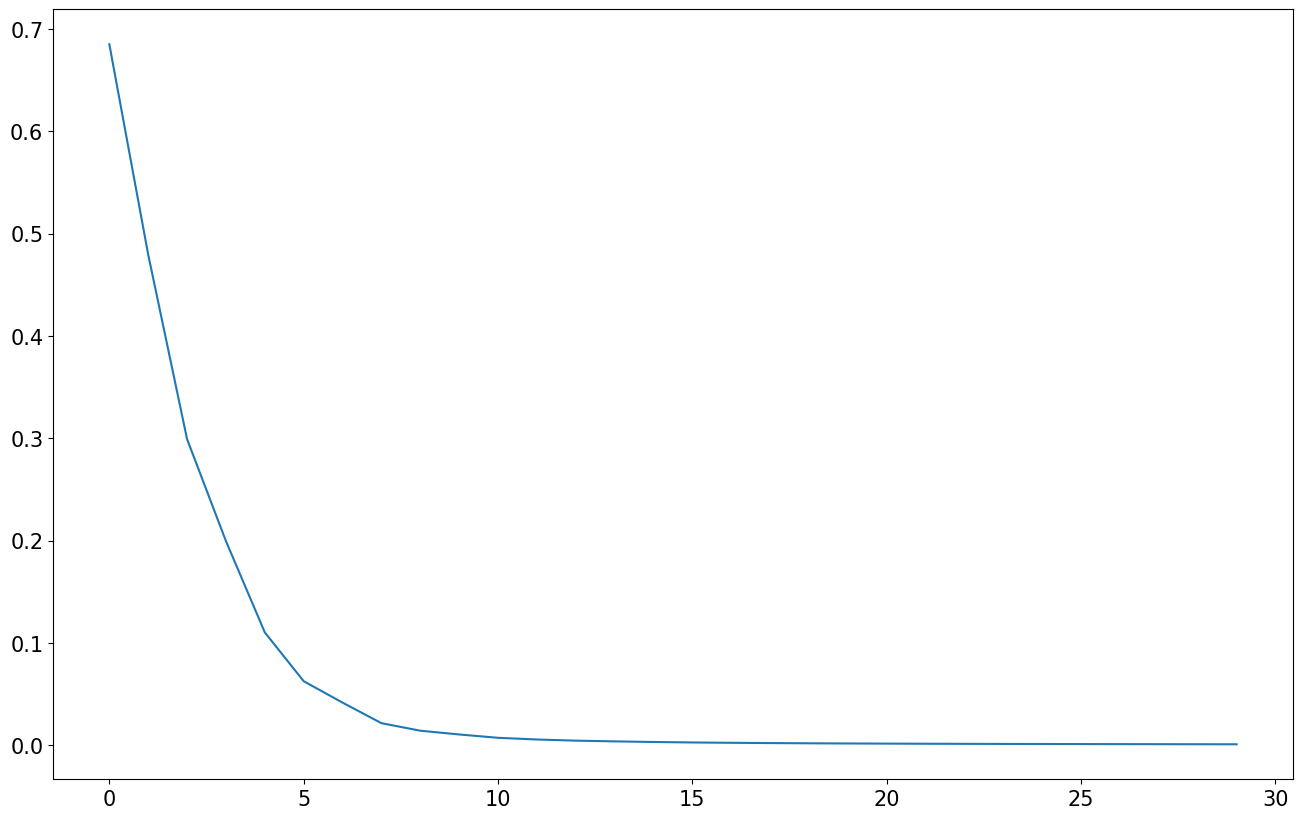

In [71]:
plt.figure()
plt.plot(tr_loss_hist)
plt.show()

# **RNN - Many-to-one stacking**

In [72]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('Tensorflow: {}'.format(tf.__version__))

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

Tensorflow: 2.20.0


In [73]:
sentences = ['What I cannot create, I do not understand',
             'Intellectuals solve problems, geniuses prevent them',
             'A person who never made a mistake never tied anything new.',
             'The same equations have the same solutions']
y = [1, 0, 0, 1]

In [74]:
char_set = ['<pad>'] + sorted(list(set(''.join(sentences))))
idx2char = {idx: char for idx, char in enumerate(char_set)}
char2idx = {char: idx for idx, char in enumerate(char_set)}

In [75]:
char_set

['<pad>',
 ' ',
 ',',
 '.',
 'A',
 'I',
 'T',
 'W',
 'a',
 'b',
 'c',
 'd',
 'e',
 'g',
 'h',
 'i',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'y']

In [76]:
idx2char

{0: '<pad>',
 1: ' ',
 2: ',',
 3: '.',
 4: 'A',
 5: 'I',
 6: 'T',
 7: 'W',
 8: 'a',
 9: 'b',
 10: 'c',
 11: 'd',
 12: 'e',
 13: 'g',
 14: 'h',
 15: 'i',
 16: 'k',
 17: 'l',
 18: 'm',
 19: 'n',
 20: 'o',
 21: 'p',
 22: 'q',
 23: 'r',
 24: 's',
 25: 't',
 26: 'u',
 27: 'v',
 28: 'w',
 29: 'y'}

In [77]:
char2idx

{'<pad>': 0,
 ' ': 1,
 ',': 2,
 '.': 3,
 'A': 4,
 'I': 5,
 'T': 6,
 'W': 7,
 'a': 8,
 'b': 9,
 'c': 10,
 'd': 11,
 'e': 12,
 'g': 13,
 'h': 14,
 'i': 15,
 'k': 16,
 'l': 17,
 'm': 18,
 'n': 19,
 'o': 20,
 'p': 21,
 'q': 22,
 'r': 23,
 's': 24,
 't': 25,
 'u': 26,
 'v': 27,
 'w': 28,
 'y': 29}

In [78]:
X = list(map(lambda sentence: [char2idx.get(char) for char in sentence], sentences))

print(X)

[[7, 14, 8, 25, 1, 5, 1, 10, 8, 19, 19, 20, 25, 1, 10, 23, 12, 8, 25, 12, 2, 1, 5, 1, 11, 20, 1, 19, 20, 25, 1, 26, 19, 11, 12, 23, 24, 25, 8, 19, 11], [5, 19, 25, 12, 17, 17, 12, 10, 25, 26, 8, 17, 24, 1, 24, 20, 17, 27, 12, 1, 21, 23, 20, 9, 17, 12, 18, 24, 2, 1, 13, 12, 19, 15, 26, 24, 12, 24, 1, 21, 23, 12, 27, 12, 19, 25, 1, 25, 14, 12, 18], [4, 1, 21, 12, 23, 24, 20, 19, 1, 28, 14, 20, 1, 19, 12, 27, 12, 23, 1, 18, 8, 11, 12, 1, 8, 1, 18, 15, 24, 25, 8, 16, 12, 1, 19, 12, 27, 12, 23, 1, 25, 15, 12, 11, 1, 8, 19, 29, 25, 14, 15, 19, 13, 1, 19, 12, 28, 3], [6, 14, 12, 1, 24, 8, 18, 12, 1, 12, 22, 26, 8, 25, 15, 20, 19, 24, 1, 14, 8, 27, 12, 1, 25, 14, 12, 1, 24, 8, 18, 12, 1, 24, 20, 17, 26, 25, 15, 20, 19, 24]]


In [79]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_sequence = 55
X = pad_sequences(sequences=X, maxlen=max_sequence, padding='post', truncating='post')

print(X)
print(y)

[[ 7 14  8 25  1  5  1 10  8 19 19 20 25  1 10 23 12  8 25 12  2  1  5  1
  11 20  1 19 20 25  1 26 19 11 12 23 24 25  8 19 11  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 5 19 25 12 17 17 12 10 25 26  8 17 24  1 24 20 17 27 12  1 21 23 20  9
  17 12 18 24  2  1 13 12 19 15 26 24 12 24  1 21 23 12 27 12 19 25  1 25
  14 12 18  0  0  0  0]
 [ 4  1 21 12 23 24 20 19  1 28 14 20  1 19 12 27 12 23  1 18  8 11 12  1
   8  1 18 15 24 25  8 16 12  1 19 12 27 12 23  1 25 15 12 11  1  8 19 29
  25 14 15 19 13  1 19]
 [ 6 14 12  1 24  8 18 12  1 12 22 26  8 25 15 20 19 24  1 14  8 27 12  1
  25 14 12  1 24  8 18 12  1 24 20 17 26 25 15 20 19 24  0  0  0  0  0  0
   0  0  0  0  0  0  0]]
[1, 0, 0, 1]


In [80]:
train_ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(buffer_size=4).batch(batch_size=2)
print(train_ds)

<_BatchDataset element_spec=(TensorSpec(shape=(None, 55), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, TimeDistributed, Dropout, Dense

input_dim = len(char2idx)
output_dim = len(char2idx)

model = Sequential([
    Embedding(input_dim=input_dim, output_dim=output_dim,
              trainable=False, mask_zero=True, input_length=max_sequence,
              embeddings_initializer=tf.keras.initializers.random_normal()),
    SimpleRNN(units=10, return_sequences=True),
    TimeDistributed(Dropout(rate=0.2)),
    SimpleRNN(units=10),
    Dense(units=2)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [82]:
# Creating loss function
def loss_fn(model, x, y):
    return tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(
        y_true=y, y_pred=model(x), from_logits=True
    ))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [83]:
tr_loss_hist = []

for e in range(30):
    avg_tr_loss = 0
    tr_step = 0

    for x_mb, y_mb in train_ds:
        with tf.GradientTape() as tape:
            tr_loss = loss_fn(model, x=x_mb, y=y_mb)
        grads = tape.gradient(target=tr_loss, sources=model.trainable_variables)
        optimizer.apply_gradients(grads_and_vars=zip(grads, model.trainable_variables))
        avg_tr_loss += tr_loss
        tr_step += 1

    avg_tr_loss /= tr_step
    tr_loss_hist.append(avg_tr_loss)

    if (e + 1) % 5 == 0:
        print('epoch: {:3}, tr_loss: {:.3f}'.format(e + 1, avg_tr_loss.numpy()))

epoch:   5, tr_loss: 0.309
epoch:  10, tr_loss: 0.060
epoch:  15, tr_loss: 0.018
epoch:  20, tr_loss: 0.009
epoch:  25, tr_loss: 0.005
epoch:  30, tr_loss: 0.004


In [84]:
prediction = model.predict(X)
prediction = np.argmax(prediction, axis=-1)
print('Accuracy: {:.2%}'.format(np.mean(prediction == y)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
Accuracy: 100.00%


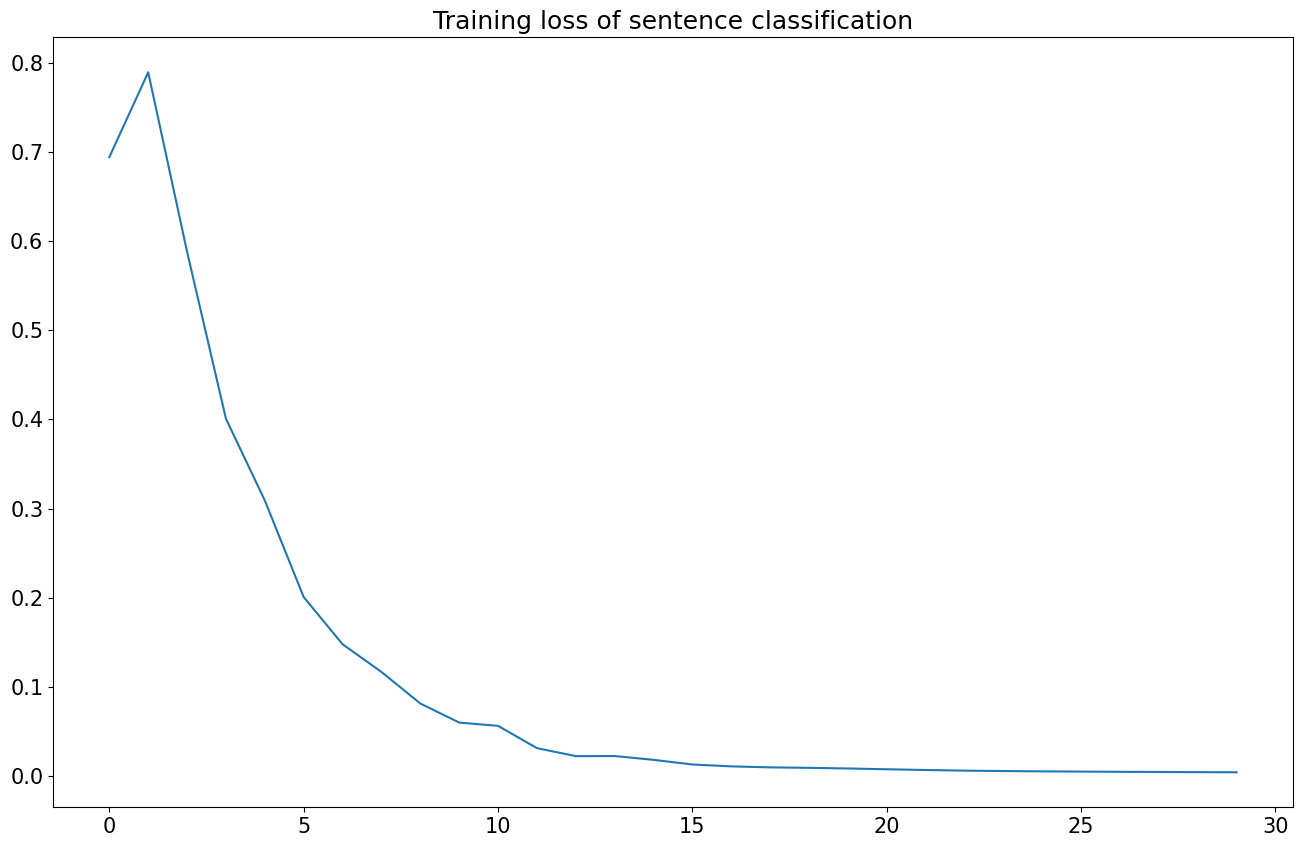

In [85]:
plt.figure()
plt.plot(tr_loss_hist)
plt.title('Training loss of sentence classification')
plt.show()